In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import classification_report, confusion_matrix, f1_score, mean_absolute_error, r2_score

sns.set_style("darkgrid")
plt.rcParams["figure.figsize"] = (10, 6)

In [11]:
df = pd.read_csv("datasets/client_training_dataset.csv")
print("Shape:", df.shape)
print("\nFault_Type_True distribution:")
print(df["Fault_Type_True"].value_counts())

Shape: (189275, 18)

Fault_Type_True distribution:
Fault_Type_True
Normal            146387
Rotor Bar          14247
Bearing Wear       11551
Misalignment        9304
Stator Winding      7786
Name: count, dtype: int64


In [12]:
FEATURE_COLS = [
    "Voltage_L1", "Voltage_L2", "Voltage_L3", "Frequency", "Power_Factor",
    "Temperature", "Vibration_X", "Vibration_Y", "Vibration_Z", "Rotational_Speed"
]

X = df[FEATURE_COLS].copy()

le = LabelEncoder()
y_class = le.fit_transform(df["Fault_Type_True"])

X_train, X_test, y_train, y_test, idx_train, idx_test = train_test_split(
    X, y_class, df.index, test_size=0.2, random_state=42, stratify=y_class
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Macro F1: 0.9523
                precision    recall  f1-score   support

  Bearing Wear       0.97      0.98      0.98      2310
  Misalignment       0.95      0.99      0.97      1861
        Normal       0.99      0.98      0.98     29277
     Rotor Bar       0.88      0.96      0.92      2850
Stator Winding       0.88      0.95      0.91      1557

      accuracy                           0.98     37855
     macro avg       0.93      0.97      0.95     37855
  weighted avg       0.98      0.98      0.98     37855



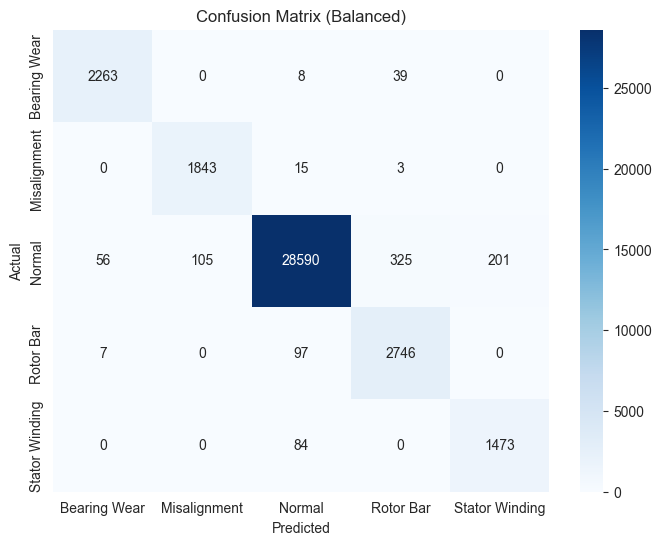

In [13]:
clf = RandomForestClassifier(
    n_estimators=150,
    max_depth=12,
    class_weight="balanced",   # <-- this is what your old notebook was missing
    random_state=42,
    n_jobs=2
)
clf.fit(X_train_scaled, y_train)

y_pred = clf.predict(X_test_scaled)
print("Macro F1:", round(f1_score(y_test, y_pred, average="macro"), 4))
print(classification_report(y_test, y_pred, target_names=le.classes_))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (Balanced)")
plt.show()

In [14]:
y_rul_train = df.loc[idx_train, "RUL_hours"]
y_rul_test = df.loc[idx_test, "RUL_hours"]

reg_rul = RandomForestRegressor(n_estimators=150, max_depth=12, random_state=42, n_jobs=2)
reg_rul.fit(X_train_scaled, y_rul_train)

rul_pred = reg_rul.predict(X_test_scaled)
print("RUL MAE:", round(mean_absolute_error(y_rul_test, rul_pred), 2), "hours")
print("RUL R2:", round(r2_score(y_rul_test, rul_pred), 4))

RUL MAE: 405.77 hours
RUL R2: 0.4562


In [15]:
y_health_train = df.loc[idx_train, "Health_Score"]
y_health_test = df.loc[idx_test, "Health_Score"]

reg_health = RandomForestRegressor(n_estimators=150, max_depth=12, random_state=42, n_jobs=2)
reg_health.fit(X_train_scaled, y_health_train)

health_pred = reg_health.predict(X_test_scaled)
print("Health Score MAE:", round(mean_absolute_error(y_health_test, health_pred), 2))
print("Health Score R2:", round(r2_score(y_health_test, health_pred), 4))

Health Score MAE: 15.92
Health Score R2: 0.4689


In [16]:
os.makedirs("models", exist_ok=True)

joblib.dump(clf, "models/condition_classifier.pkl")
joblib.dump(reg_rul, "models/rul_regressor.pkl")
joblib.dump(reg_health, "models/health_regressor.pkl")
joblib.dump(scaler, "models/feature_scaler.pkl")
joblib.dump(le, "models/label_encoder.pkl")
print("Models saved to models/ folder")

Models saved to models/ folder
